# 05 - Génération du jeu de données d'entraînement (patchs + augmentation)

**Objectif :** construire le jeu de données final pour l'entraînement du U-Net,
à partir des masques (Phase 1) : découpage en patchs 256×256 (dimensionné pour
une GPU 4 Go de VRAM) + augmentation (rotations, symétries, luminosité, bruit).

**Stratégie de patchs :**
- 1 patch centré sur chaque pièce (garantit que les 125 pièces sont représentées)
- 10 patchs à position aléatoire par tracé (diversité de fond/texte/bruit)
- 3 versions augmentées par patch brut

**Point de vigilance déjà vérifié** (notebook de développement) : l'alignement
image/masque reste parfait après transformation, testé sur plusieurs
augmentations successives — aucun désalignement observé.


In [1]:
import sys
!{sys.executable} -m pip install albumentations

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl (43.8 MB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached annotated_types-0.8.0-py3-none-any.whl (13 kB)

   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   -----------------------------------

In [2]:
import sys
sys.path.append('../src')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from acquisition.pdf_loader import rasterize_pdf, get_pdf_page_size_cm
from segmentation.dataset_prep import generate_masks
from segmentation.augmentation import build_dataset, save_dataset, extract_raw_patches, augment_patch, get_train_transform

REFERENCE_DIR = Path('../data/raw/reference')
ANNOTATIONS_DIR = Path('../data/processed')
PATCHES_DIR = Path('../data/processed/patches')

TRACEES = ['Tracee1', 'Tracee2', 'Tracee3', 'Tracee4']
PATCH_SIZE = 256  # dimensionne pour GPU 4Go de VRAM (GTX 1650)

## 1. Chargement des masques des 4 tracés

In [3]:
all_masks = {}

for name in TRACEES:
    pdf_path = str(REFERENCE_DIR / f'{name}.pdf')
    ann_path = str(ANNOTATIONS_DIR / f'{name}_annotations.json')

    img = rasterize_pdf(pdf_path, dpi=100)
    w_cm, h_cm = get_pdf_page_size_cm(pdf_path)
    h_px, w_px = img.shape[:2]
    scale_orig = ((w_cm / w_px) + (h_cm / h_px)) / 2

    masks = generate_masks(img, ann_path, scale_orig, target_max_dim=1536)
    all_masks[name] = masks
    print(f"{name}: masques charges ({masks.n_pieces} pieces)")

Tracee1: masques charges (25 pieces)
Tracee2: masques charges (40 pieces)
Tracee3: masques charges (23 pieces)
Tracee4: masques charges (37 pieces)


## 2. Vérification de l'alignement image/masque après augmentation

Contrôle rapide avant de générer tout le jeu de données : on augmente un même
patch plusieurs fois et on vérifie visuellement que le masque colle toujours
au bord de la pièce, peu importe la transformation appliquée.

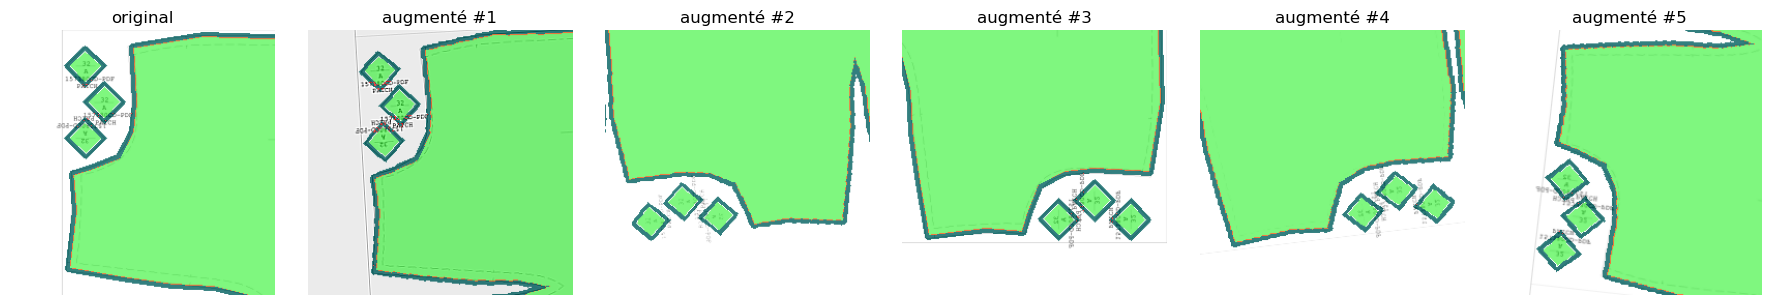

Vérifie à l'oeil : le masque vert/rouge doit coller au bord de la pièce dans chaque panneau.


In [4]:
patch_test = extract_raw_patches(all_masks['Tracee1'], patch_size=PATCH_SIZE, n_random_patches=5)[3]
transform = get_train_transform(PATCH_SIZE)

def overlay(p):
    out = p.image.copy()
    out[p.mask_interieur > 0] = (0.5*out[p.mask_interieur > 0] + np.array([0,120,0])).astype('uint8')
    out[p.mask_frontiere > 0] = (0.5*out[p.mask_frontiere > 0] + np.array([0,0,180])).astype('uint8')
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(overlay(patch_test)); axes[0].set_title('original'); axes[0].axis('off')
for i in range(1, 6):
    aug = augment_patch(patch_test, transform)
    axes[i].imshow(overlay(aug)); axes[i].set_title(f'augmenté #{i}'); axes[i].axis('off')
plt.tight_layout()
plt.savefig('../data/processed/05_verification_alignement.png', dpi=80)
plt.show()

print("Vérifie à l'oeil : le masque vert/rouge doit coller au bord de la pièce dans chaque panneau.")

## 3. Génération du jeu de données complet (4 tracés)

In [5]:
dataset = build_dataset(
    all_masks,
    patch_size=PATCH_SIZE,
    n_random_patches_per_tracee=10,
    n_augmentations_per_patch=3,
)

from collections import Counter
counts = Counter(p.tracee_source for p in dataset)
counts_brut = Counter(p.tracee_source for p in dataset if not p.est_augmente)
counts_aug = Counter(p.tracee_source for p in dataset if p.est_augmente)

print(f"{'Tracé':10s} {'Patchs bruts':14s} {'Patchs augmentés':18s} {'Total'}")
print("-" * 55)
for name in TRACEES:
    print(f"{name:10s} {counts_brut[name]:<14d} {counts_aug[name]:<18d} {counts[name]}")
print("-" * 55)
print(f"{'TOTAL':10s} {'':14s} {'':18s} {len(dataset)}")

Tracé      Patchs bruts   Patchs augmentés   Total
-------------------------------------------------------
Tracee1    35             105                140
Tracee2    50             150                200
Tracee3    33             99                 132
Tracee4    47             141                188
-------------------------------------------------------
TOTAL                                        660


## 4. Sauvegarde sur disque

In [6]:
save_dataset(dataset, str(PATCHES_DIR))
print(f"{len(dataset)} patchs sauvegardes dans {PATCHES_DIR}/, organises par tracé source")
print("(structure : patches/TraceeN/patch_XXXX_[brut|aug]_[image|interieur|frontiere].png)")

660 patchs sauvegardes dans ..\data\processed\patches/, organises par tracé source
(structure : patches/TraceeN/patch_XXXX_[brut|aug]_[image|interieur|frontiere].png)


## Prochaines étapes

1. Architecture et entraînement du U-Net (Phase 3) : encodeur léger (ResNet18/
   MobileNet), précision mixte, batch size adapté à la GPU 4Go
2. Validation leave-one-tracé-out : entraîner sur 3 tracés, valider sur le 4ème
   (répété 4 fois) — les patchs étant déjà organisés par dossier `TraceeN/`,
   cette séparation sera directe
3. Extraction des points de contour depuis les masques prédits (Phase 5)


oki tous claire on faire ce travail garde meme niveau professionnal est bien redigie est fonctionne just a vous connaissance lorsque tu train de charge de donne mettre que apres fichier processed j'avais pas de fichier annotation je travail comme sa on continue de ce facon 